In [2]:
import os
import subprocess
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from datetime import datetime
import time
import glob
import ast
import re

In [3]:
DATA_DIR = "./x-24-us-election"
OUTPUT_PREFIX = "x_24_us_election"
SKIP_DOWNLOAD = False

PARTS_CONFIG = {
    20: (381, 400),    # part_1: chunk 1-20
}

USE_TIME_FILTER = True
START_DATE = '2024-05-13'   
END_DATE = '2024-05-20'

In [4]:
start_time = time.time()
print(f"\nConfig: {len(PARTS_CONFIG)} part(s)")
for part_num, (start, end) in PARTS_CONFIG.items():
    print(f"Part {part_num}: chunk {start}-{end}")
print(f"Time: {START_DATE} to {END_DATE}" if USE_TIME_FILTER else "  Time: No filter")


Config: 1 part(s)
Part 20: chunk 381-400
Time: 2024-05-13 to 2024-05-20


In [5]:
def download_data(parts_config):
    if not os.path.exists(DATA_DIR):
        print("\nDownloading data...")
        subprocess.run([
            'git', 'clone', '--filter=blob:none', '--sparse',
            'https://github.com/sinking8/x-24-us-election.git', DATA_DIR
        ], check=True)
        os.chdir(DATA_DIR)
        subprocess.run(['git', 'sparse-checkout', 'init', '--cone'], check=True)
        os.chdir('..')

    os.chdir(DATA_DIR)
    for part_num in parts_config.keys():
        subprocess.run(['git', 'sparse-checkout', 'add', f'part_{part_num}'], check=False)
    os.chdir('..')
    print("\nData downloaded.")

if not SKIP_DOWNLOAD:
    download_data(PARTS_CONFIG)


Data downloaded.


In [6]:
def find_data_files(parts_config):
    all_files = []
    for part_num, (chunk_start, chunk_end) in parts_config.items():
        part_dir = os.path.join(DATA_DIR, f'part_{part_num}')
        if not os.path.exists(part_dir):
            print(f"part_{part_num} doesn't exist.")
            continue

        print(f"\npart_{part_num}:")
        for i in range(chunk_start, chunk_end + 1):
            matches = glob.glob(os.path.join(part_dir, f"*chunk_{i}.csv.gz"))
            if matches:
                all_files.append(matches[0])
                size_mb = os.path.getsize(matches[0]) / 1024 / 1024
                print(f"chunk_{i}: {os.path.basename(matches[0])} ({size_mb:.1f}MB)")
            else:
                print(f"chunk_{i} doesn't exist.")
    print(f"Find {len(all_files)} data files.")
    return all_files

files = find_data_files(PARTS_CONFIG)
if not files:
    print("No data files found.")


part_20:
chunk_381: may_july_chunk_381.csv.gz (18.5MB)
chunk_382: may_july_chunk_382.csv.gz (19.4MB)
chunk_383: may_july_chunk_383.csv.gz (19.0MB)
chunk_384: may_july_chunk_384.csv.gz (19.9MB)
chunk_385: may_july_chunk_385.csv.gz (19.2MB)
chunk_386: may_july_chunk_386.csv.gz (19.4MB)
chunk_387: may_july_chunk_387.csv.gz (19.4MB)
chunk_388: may_july_chunk_388.csv.gz (18.8MB)
chunk_389: may_july_chunk_389.csv.gz (19.1MB)
chunk_390: may_july_chunk_390.csv.gz (19.1MB)
chunk_391: may_july_chunk_391.csv.gz (19.1MB)
chunk_392: may_july_chunk_392.csv.gz (19.2MB)
chunk_393: may_july_chunk_393.csv.gz (19.3MB)
chunk_394: may_july_chunk_394.csv.gz (19.2MB)
chunk_395: may_july_chunk_395.csv.gz (18.9MB)
chunk_396: may_july_chunk_396.csv.gz (18.6MB)
chunk_397: may_july_chunk_397.csv.gz (19.1MB)
chunk_398: may_july_chunk_398.csv.gz (19.5MB)
chunk_399: may_july_chunk_399.csv.gz (18.2MB)
chunk_400: may_july_chunk_400.csv.gz (19.3MB)
Find 20 data files.


In [7]:
def load_and_filter_data(files):
    dfs = []
    for i, f in enumerate(files, 1):
        print(f"\n[{i}/{len(files)}] {os.path.basename(f)}", end=" ... ")
        try:
            df = pd.read_csv(f, compression='gzip')
            dfs.append(df)
        except Exception as e:
            print(f"{e}")

    df = pd.concat(dfs, ignore_index=True)

    df = df.drop_duplicates(subset=['id'], keep='first')
    
    if USE_TIME_FILTER:
        df['datetime'] = pd.to_datetime(df['epoch'], unit='s', errors='coerce')
        df = df[df['datetime'].notna()]
        mask = (df['datetime'] >= pd.to_datetime(START_DATE)) & \
               (df['datetime'] <= pd.to_datetime(END_DATE))
        df = df[mask]
     
    print(f"\n{len(df):,} tweets")
    
    retweets = df[df['retweetedUserID'].notna()].copy()
    print(f"\nRetweets: {len(retweets):,} ({len(retweets)/len(df)*100:.1f}%)")

    USER_ID_RE = re.compile(r"'id_str':\s*'(\d+)'|\'id\':\s*(\d+)")

    def parse_user_id(val):
        if isinstance(val, dict):
            return str(val.get('id_str') or val.get('id'))
        if isinstance(val, str):
            match = USER_ID_RE.search(val)
            if match:
                return match.group(1) or match.group(2)
        return None

    df['user_id'] = df['user'].map(parse_user_id)
    retweets['user_id'] = retweets['user'].map(parse_user_id)

    retweets['retweetedUserID'] = (
        retweets['retweetedUserID']
        .apply(lambda x: str(int(float(x))) if pd.notna(x) else None)
    )



    return df, retweets

df, retweets = load_and_filter_data(files)
if len(retweets) == 0:
    print("No retweet data.")


[1/20] may_july_chunk_381.csv.gz ... 
[2/20] may_july_chunk_382.csv.gz ... 
[2/20] may_july_chunk_382.csv.gz ... 
[3/20] may_july_chunk_383.csv.gz ... 
[3/20] may_july_chunk_383.csv.gz ... 
[4/20] may_july_chunk_384.csv.gz ... 
[4/20] may_july_chunk_384.csv.gz ... 
[5/20] may_july_chunk_385.csv.gz ... 
[5/20] may_july_chunk_385.csv.gz ... 
[6/20] may_july_chunk_386.csv.gz ... 
[6/20] may_july_chunk_386.csv.gz ... 

/var/folders/6b/j0xnvjg94072mz8tv8vwjvdw0000gn/T/ipykernel_13487/4080391563.py:6: DtypeWarning: Columns (6,7,8,9,17,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, compression='gzip')



[7/20] may_july_chunk_387.csv.gz ... 
[8/20] may_july_chunk_388.csv.gz ... 
[8/20] may_july_chunk_388.csv.gz ... 
[9/20] may_july_chunk_389.csv.gz ... 
[9/20] may_july_chunk_389.csv.gz ... 
[10/20] may_july_chunk_390.csv.gz ... 
[10/20] may_july_chunk_390.csv.gz ... 
[11/20] may_july_chunk_391.csv.gz ... 
[11/20] may_july_chunk_391.csv.gz ... 
[12/20] may_july_chunk_392.csv.gz ... 
[12/20] may_july_chunk_392.csv.gz ... 
[13/20] may_july_chunk_393.csv.gz ... 
[13/20] may_july_chunk_393.csv.gz ... 
[14/20] may_july_chunk_394.csv.gz ... 
[14/20] may_july_chunk_394.csv.gz ... 
[15/20] may_july_chunk_395.csv.gz ... 
[15/20] may_july_chunk_395.csv.gz ... 
[16/20] may_july_chunk_396.csv.gz ... 
[16/20] may_july_chunk_396.csv.gz ... 
[17/20] may_july_chunk_397.csv.gz ... 
[17/20] may_july_chunk_397.csv.gz ... 
[18/20] may_july_chunk_398.csv.gz ... 
[18/20] may_july_chunk_398.csv.gz ... 
[19/20] may_july_chunk_399.csv.gz ... 
[19/20] may_july_chunk_399.csv.gz ... 
[20/20] may_july_chunk_400.cs

In [8]:
def build_network(df, retweets):
    G = nx.DiGraph()
    
    all_users = set(df['user_id'].dropna().astype(str))
    G.add_nodes_from(all_users)

    edges_df = retweets[
        retweets['user_id'].notna() &
        retweets['retweetedUserID'].notna()
    ]

    edges = list(
        zip(
            edges_df['user_id'].astype(str),
            edges_df['retweetedUserID'].astype(str)
        )
    )

    G.add_edges_from(edges)

    print(f"Nodes: {G.number_of_nodes():,}")
    print(f"Edges: {G.number_of_edges():,}")
    print(f"Isolated nodes: {nx.number_of_isolates(G):,}")
    
    return G

G = build_network(df, retweets)

Nodes: 7,219
Edges: 6,891
Isolated nodes: 258


In [9]:
def export_network(G, parts_config):
    if len(parts_config) == 1:
        part_num = list(parts_config.keys())[0]
        start, end = parts_config[part_num]
        suffix = f"part{part_num}_chunk{start}-{end}"
    else:
        suffix = "multipart_" + "_".join([f"p{p}" for p in sorted(parts_config.keys())])

    gexf_path = f"{OUTPUT_PREFIX}_{suffix}.gexf"
    nx.write_gexf(G, gexf_path)
    print({gexf_path})

export_network(G, PARTS_CONFIG)

{'x_24_us_election_part20_chunk381-400.gexf'}


In [10]:
def analyze_network(G):
    """
    Performs structural analysis on the constructed network.
    Does NOT modify the graph structure.
    Style: Clean single-line separators.
    """
    sep_line = "-" * 60 
    
    print("\n" + sep_line)
    print("PHASE 2: NETWORK STRUCTURE ANALYSIS (Topology)")
    print(sep_line)

    # ---------------------------------------------------------
    # 1. Basic Overview
    # ---------------------------------------------------------
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    density = nx.density(G)
    reciprocity = nx.reciprocity(G)
    
    print(f"[1] Network Overview")
    print(f"    - Nodes (Users)        : {num_nodes:,}")
    print(f"    - Edges (Interactions) : {num_edges:,}")
    print(f"    - Network Density      : {density:.6e}")
    print(f"    - Reciprocity          : {reciprocity:.4f}")

    # ---------------------------------------------------------
    # 2. Degree Analysis
    # ---------------------------------------------------------
    print(f"\n[2] Degree Analysis")
    in_degrees = [d for n, d in G.in_degree()]
    out_degrees = [d for n, d in G.out_degree()]

    avg_in = np.mean(in_degrees)
    max_in = np.max(in_degrees)
    avg_out = np.mean(out_degrees)
    max_out = np.max(out_degrees)

    print(f"    - Avg In-Degree (Influence) : {avg_in:.2f} (Max: {max_in:,})")
    print(f"    - Avg Out-Degree (Activity) : {avg_out:.2f} (Max: {max_out:,})")

    # Plot Log-Log Degree Distribution
    try:
        plt.figure(figsize=(12, 5))
        
        # In-Degree
        plt.subplot(1, 2, 1)
        bins_in = np.logspace(np.log10(1), np.log10(max_in+1), 50)
        plt.hist(in_degrees, bins=bins_in, alpha=0.7, color='#1f77b4', log=True)
        plt.xscale('log')
        plt.yscale('log')
        plt.title('In-Degree Distribution (Influence)')
        plt.xlabel('Degree (k)')
        plt.ylabel('Frequency P(k)')
        
        # Out-Degree
        plt.subplot(1, 2, 2)
        bins_out = np.logspace(np.log10(1), np.log10(max_out+1), 50)
        plt.hist(out_degrees, bins=bins_out, alpha=0.7, color='#ff7f0e', log=True)
        plt.xscale('log')
        plt.yscale('log')
        plt.title('Out-Degree Distribution (Activity)')
        plt.xlabel('Degree (k)')
        
        plt.tight_layout()
        plt.savefig(f"{OUTPUT_PREFIX}_degree_dist.png")
        print(f"    -> Plot saved: {OUTPUT_PREFIX}_degree_dist.png")
        plt.close()
    except Exception as e:
        print(f"    -> Plotting failed: {e}")

    # ---------------------------------------------------------
    # 3. Connectivity & Components
    # ---------------------------------------------------------
    print(f"\n[3] Connectivity & Components")
    if num_nodes > 0:
        wcc = list(nx.weakly_connected_components(G))
        largest_wcc = max(wcc, key=len)
        print(f"    - Weakly Connected Components : {len(wcc):,}")
        print(f"    - Giant Component Size (WCC)  : {len(largest_wcc):,} ({(len(largest_wcc)/num_nodes)*100:.1f}%)")
        
        scc = list(nx.strongly_connected_components(G))
        largest_scc = max(scc, key=len)
        print(f"    - Largest Strongly Connected (LSCC): {len(largest_scc):,}")
        
        if 1 < len(largest_scc) < 3000:
            sub_g = G.subgraph(largest_scc)
            avg_path = nx.average_shortest_path_length(sub_g)
            print(f"    - Avg Path Length (in LSCC)   : {avg_path:.4f}")
        else:
            print(f"    - Avg Path Length             : Skipped (LSCC size {len(largest_scc):,})")

    # ---------------------------------------------------------
    # 4. Clustering Coefficients
    # ---------------------------------------------------------
    print(f"\n[4] Clustering Analysis")
    try:
        transitivity = nx.transitivity(G)
        print(f"    - Transitivity (Global) : {transitivity:.6f}")
    except:
        print("    - Transitivity calculation failed.")

    # ---------------------------------------------------------
    # 5. Assortativity
    # ---------------------------------------------------------
    print(f"\n[5] Assortativity Analysis")
    try:
        r = nx.degree_assortativity_coefficient(G)
        print(f"    - Degree Assortativity  : {r:.4f}")
        if r > 0:
            print("      (Positive: Hubs connect to Hubs)")
        else:
            print("      (Negative: Hubs connect to Small Nodes)")
    except:
        print("    - Assortativity calculation failed.")

    # ---------------------------------------------------------
    # 6. Centrality Measures
    # ---------------------------------------------------------
    print(f"\n[6] Centrality Analysis (Top 10)")
    
    top_in_degree = sorted(G.in_degree(), key=lambda x: x[1], reverse=True)[:10]
    print("\n    [Most Retweeted Users (In-Degree)]")
    for i, (user, deg) in enumerate(top_in_degree, 1):
        print(f"    {i:2d}. User {user:<20} : {deg}")

    print("\n    [Calculating PageRank...]")
    try:
        pr = nx.pagerank(G, alpha=0.85)
        top_pr = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:10]
        print("    [Top Authority Users (PageRank)]")
        for i, (user, score) in enumerate(top_pr, 1):
            print(f"    {i:2d}. User {user:<20} : {score:.6f}")
            
        with open(f"{OUTPUT_PREFIX}_centrality_results.txt", "w") as f:
            f.write("Rank,Type,User_ID,Score\n")
            for i, (u, s) in enumerate(top_pr, 1):
                f.write(f"{i},PageRank,{u},{s}\n")
            for i, (u, s) in enumerate(top_in_degree, 1):
                f.write(f"{i},InDegree,{u},{s}\n")
        print(f"    -> Centrality results saved to {OUTPUT_PREFIX}_centrality_results.txt")
        
    except Exception as e:
        print(f"    -> PageRank failed: {e}")

    print("\n" + sep_line)

analyze_network(G)


------------------------------------------------------------
PHASE 2: NETWORK STRUCTURE ANALYSIS (Topology)
------------------------------------------------------------
[1] Network Overview
    - Nodes (Users)        : 7,219
    - Edges (Interactions) : 6,891
    - Network Density      : 1.322478e-04
    - Reciprocity          : 0.0000

[2] Degree Analysis
    - Avg In-Degree (Influence) : 0.95 (Max: 379)
    - Avg Out-Degree (Activity) : 0.95 (Max: 14)
    -> Plot saved: x_24_us_election_degree_dist.png

[3] Connectivity & Components
    - Weakly Connected Components : 916
    - Giant Component Size (WCC)  : 4,862 (67.4%)
    - Largest Strongly Connected (LSCC): 1
    - Avg Path Length             : Skipped (LSCC size 1)

[4] Clustering Analysis
    - Transitivity (Global) : 0.001187

[5] Assortativity Analysis
    - Degree Assortativity  : -0.0803
      (Negative: Hubs connect to Small Nodes)

[6] Centrality Analysis (Top 10)

    [Most Retweeted Users (In-Degree)]
     1. User 1486

In [11]:
elapsed = time.time() - start_time
print(f"Done. Time: {elapsed/60:.1f} min")

Done. Time: 0.5 min


# Diffusion analysis using SI based baseline modeling

In [12]:
def prepare_diffusion_data(df, retweets, G, top_n=20):
    # original_post_ids = retweets['retweetedTweetID'].dropna().unique()
    # print(f"Total unique posts that were retweeted: {len(original_post_ids):,}")
    
    retweet_counts = retweets.groupby('retweetedTweetID').size().reset_index(name='retweet_count')
    retweet_counts = retweet_counts.sort_values('retweet_count', ascending=False)
    
    top_posts = retweet_counts.head(top_n).copy()
    # print(f"Selected top {top_n} most retweeted posts")
    # print(f"Retweet range: {top_posts['retweet_count'].min():,} to {top_posts['retweet_count'].max():,}")

    diffusion_data = {}
    
    for idx, (post_id, rt_count) in enumerate(zip(top_posts['retweetedTweetID'], 
                                                    top_posts['retweet_count']), 1):
        # print(f"\n[{idx}/{top_n}] Post ID: {post_id} ({rt_count:,} retweets)")
        
        post_retweets = retweets[retweets['retweetedTweetID'] == post_id].copy()
        
        original_post = df[df['id'] == post_id]
        
        if len(original_post) > 0:
            original_time = original_post.iloc[0]['datetime']
            original_user = original_post.iloc[0]['user_id']
        else:
            original_time = post_retweets['datetime'].min()
            original_user = post_retweets.iloc[0]['retweetedUserID']
            # print(f" Warning: Original post not in dataset, using first retweet time")
        
        post_retweets['relative_time_hours'] = (
            (post_retweets['datetime'] - original_time).dt.total_seconds() / 3600
        )
        
        post_retweets = post_retweets.sort_values('relative_time_hours')
        post_retweets['cumulative_retweets'] = range(1, len(post_retweets) + 1)
        
        time_series = post_retweets[['relative_time_hours', 'cumulative_retweets']].copy()
        
        retweeting_users = set(post_retweets['user_id'].dropna().astype(str))
        retweeted_users = set(post_retweets['retweetedUserID'].dropna().astype(str))
        all_users = retweeting_users | retweeted_users
        
        subgraph_nodes = [n for n in all_users if n in G.nodes()]
        subgraph = G.subgraph(subgraph_nodes).copy()
        
        # print(f"Time series: {len(time_series)} data points")
        # print(f"Time span: {time_series['relative_time_hours'].max():.1f} hours")
        # print(f"Subgraph: {subgraph.number_of_nodes():,} nodes, "
        #       f"{subgraph.number_of_edges():,} edges")
        
        diffusion_data[post_id] = {
            'post_id': post_id,
            'original_time': original_time,
            'original_user': original_user,
            'total_retweets': rt_count,
            'time_series': time_series,
            'retweet_details': post_retweets,
            'subgraph': subgraph,
            'participating_users': all_users
        }
    
    summary_df = pd.DataFrame([
        {
            'post_id': post_id,
            'total_retweets': data['total_retweets'],
            'time_span_hours': data['time_series']['relative_time_hours'].max(),
            'subgraph_nodes': data['subgraph'].number_of_nodes(),
            'subgraph_edges': data['subgraph'].number_of_edges(),
            'original_user': data['original_user']
        }
        for post_id, data in diffusion_data.items()
    ])
    
    summary_path = f"{OUTPUT_PREFIX}_diffusion_analysis.csv"
    summary_df.to_csv(summary_path, index=False)
    # print(f"Summary saved to {summary_path}")
    
    return diffusion_data, top_posts

diffusion_data, top_posts = prepare_diffusion_data(df, retweets, G, top_n=20)

In [35]:
def run_SI_simulation(G, seed_node, beta, max_steps=100, n_runs=500):
    all_runs = []
    
    for run in range(n_runs):
        # 0 = Susceptible, 1 = Infected
        state = {node: 0 for node in G.nodes()}
        
        if seed_node not in state:
            if len(G.nodes()) > 0:
                seed_node = list(G.nodes())[0]
            else:
                continue
        
        state[seed_node] = 1
        
        infected_count = [1]
        
        for t in range(max_steps):
            infected_nodes = [node for node, s in state.items() if s == 1]
            
            if len(infected_nodes) == 0:
                break
            
            newly_infected = []
            
            for infected_node in infected_nodes:
                neighbors = list(G.predecessors(infected_node))
                
                for neighbor in neighbors:
                    if state[neighbor] == 0:
                        if np.random.random() < beta:
                            newly_infected.append(neighbor)
            
            for node in newly_infected:
                state[node] = 1
            
            total_infected = sum(state.values())
            infected_count.append(total_infected)
            
            if len(newly_infected) == 0:
                break
        
        all_runs.append(infected_count)
    
    max_length = max(len(run) for run in all_runs) if all_runs else 0
    
    padded_runs = []
    for run in all_runs:
        if len(run) < max_length:
            final_value = run[-1]
            padded_run = run + [final_value] * (max_length - len(run))
        else:
            padded_run = run
        padded_runs.append(padded_run)
    
    runs_array = np.array(padded_runs)
    mean_infected = np.mean(runs_array, axis=0)
    std_infected = np.std(runs_array, axis=0)
    
    ci_lower = np.percentile(runs_array, 2.5, axis=0)
    ci_upper = np.percentile(runs_array, 97.5, axis=0)
    
    results = {
        'mean': mean_infected,
        'std': std_infected,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'all_runs': padded_runs,
        'n_runs': n_runs,
        'beta': beta,
        'seed_node': seed_node,
        'max_steps': max_length
    }
    
    return results

In [36]:
def estimate_beta_from_empirical(empirical_data, G, method='early_growth'):
    ts = empirical_data['time_series']
    total_time = ts['relative_time_hours'].max()
    total_retweets = empirical_data['total_retweets']
    
    if total_time <= 0 or total_retweets <= 1:
        return 0.001
    
    if method == 'early_growth':
        early_cutoff = int(len(ts) * 0.2)
        early_cutoff = max(early_cutoff, 2)
        
        early_ts = ts.head(early_cutoff).copy()
        
        if len(early_ts) >= 2:
            from scipy.stats import linregress
            
            valid_idx = early_ts['cumulative_retweets'] > 0
            if valid_idx.sum() >= 2:
                x = early_ts.loc[valid_idx, 'relative_time_hours'].values
                y = np.log(early_ts.loc[valid_idx, 'cumulative_retweets'].values)
                
                slope, intercept, r_value, p_value, std_err = linregress(x, y)
                growth_rate = slope
                
                in_degrees = [d for n, d in G.in_degree() if d > 0]
                avg_degree = np.mean(in_degrees) if in_degrees else 1.0
                
                beta = growth_rate / avg_degree if avg_degree > 0 else 0.001
                beta = max(0.0001, min(0.5, beta))
                
                # print(f"\n[Early Growth Estimation]")
                # print(f"Growth rate r = {growth_rate:.4f} per hour")
                # print(f"Avg in-degree = {avg_degree:.2f}")
                # print(f"Estimated β = {beta:.6f}")
                # print(f"R² = {r_value**2:.4f}")
                
                return beta
            
    elif method == 'average_rate':
        hourly_rate = total_retweets / total_time
        in_degrees = [d for n, d in G.in_degree() if d > 0]
        avg_in_degree = np.mean(in_degrees) if in_degrees else 1.0
        network_size = G.number_of_nodes()
        
        beta = hourly_rate / (network_size * avg_in_degree)
        beta = max(0.0001, min(0.05, beta))

        # print(f"\n[Average Rate Estimation]")
        # print(f"Hourly rate = {hourly_rate:.2f} retweets/hour")
        # print(f"Estimated β = {beta:.6f}")

        return beta
    
    elif method == 'grid_search':
        print("\n[Grid Search - This may take a while...]")
        
        beta_candidates = np.logspace(-4, 0, 25)  # 0.0001 to 1.0 (扩大范围)
        best_beta = 0.001
        best_error = float('inf')
        
        from tqdm import tqdm
        
        for beta_test in tqdm(beta_candidates, desc="Testing β values"):
            sim_results = run_SI_simulation(
                G=G,
                seed_node=empirical_data['original_user'],
                beta=beta_test,
                max_steps=min(100, len(ts)),
                n_runs=50
            )

            sim_final = sim_results['mean'][-1]
            emp_final = total_retweets
            error = abs(sim_final - emp_final)
            
            if error < best_error:
                best_error = error
                best_beta = beta_test
        
        # print(f"Best β = {best_beta:.6f} (RMSE = {best_error:.2f})")
        
        return best_beta
    
    return 0.001


test_post_id = list(diffusion_data.keys())[0]
test_data = diffusion_data[test_post_id]

beta_early = estimate_beta_from_empirical(test_data, test_data['subgraph'], method='early_growth')
beta_avg = estimate_beta_from_empirical(test_data, test_data['subgraph'], method='average_rate')
beta_grid = estimate_beta_from_empirical(test_data, test_data['subgraph'], method='grid_search')


[Grid Search - This may take a while...]


Testing β values: 100%|██████████| 25/25 [00:00<00:00, 29.93it/s] 


In [37]:
# sim_results_estimated = run_SI_simulation(
#     G=test_data['subgraph'],
#     seed_node=test_data['original_user'],
#     beta=beta_early,
#     max_steps=100,
#     n_runs=500
# )

# print(f"\n[Simulation Results with β={beta_early:.6f}]")
# print(f"Mean final infected: {sim_results_estimated['mean'][-1]:.1f}")
# print(f"Actual retweets: {test_data['total_retweets']}")
# print(f"Difference: {abs(sim_results_estimated['mean'][-1] - test_data['total_retweets']):.1f} "
#       f"({abs(sim_results_estimated['mean'][-1] - test_data['total_retweets'])/test_data['total_retweets']*100:.1f}%)")

# sim_results_baseline = run_SI_simulation(
#     G=test_data['subgraph'],
#     seed_node=test_data['original_user'],
#     beta=beta_grid,
#     max_steps=100,
#     n_runs=500
# )

# print(f"\n[Beta_grid Simulation with β={beta_grid:.6f}]")
# print(f"Mean final infected: {sim_results_baseline['mean'][-1]:.1f}")
# print(f"Difference from actual: {abs(sim_results_baseline['mean'][-1] - test_data['total_retweets']):.1f}")

# empirical_time_to_90 = test_data['time_series'][
#     test_data['time_series']['cumulative_retweets'] >= test_data['total_retweets'] * 0.9
# ]['relative_time_hours'].min()

# sim_90_threshold = sim_results_estimated['mean'][-1] * 0.9
# sim_time_to_90 = np.where(sim_results_estimated['mean'] >= sim_90_threshold)[0]
# sim_time_to_90 = sim_time_to_90[0] if len(sim_time_to_90) > 0 else len(sim_results_estimated['mean'])

# print(f"\n[Diffusion Speed Comparison]")
# print(f"Empirical: reached 90% in {empirical_time_to_90:.1f} hours")
# print(f"SI Model:  reached 90% in {sim_time_to_90} time steps")
# print(f"Speed ratio: {empirical_time_to_90/sim_time_to_90:.2f}x")

# if empirical_time_to_90 < sim_time_to_90:
#     print(f"Real diffusion is FASTER than predicted (possible external boost)")
# else:
#     print(f"Real diffusion is SLOWER than predicted (possible constraints)")

In [40]:
sim_results = run_SI_simulation(
    G=test_data['subgraph'],
    seed_node=test_data['original_user'],
    beta=beta_grid,
    max_steps=100,
    n_runs=500
)

print(f"Mean final infected: {sim_results['mean'][-1]:.1f}")
print(f"Actual retweets: {test_data['total_retweets']}")
print(f"Simulation steps: {sim_results['max_steps']}")

Mean final infected: 177.9
Actual retweets: 178
Simulation steps: 13


In [58]:
def plot_SI_comparison(empirical_data, sim_results, post_id):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1 = axes[0]
    
    emp_ts = empirical_data['time_series']
    ax1.plot(emp_ts['relative_time_hours'], 
             emp_ts['cumulative_retweets'],
             'b-', linewidth=2.5, label='Empirical Data', alpha=0.8)
    
    time_steps = np.arange(len(sim_results['mean']))
    ax1.plot(time_steps, sim_results['mean'], 
             'r--', linewidth=2, label=f'SI Model (β={sim_results["beta"]:.3f})')
    
    ax1.fill_between(time_steps, 
                      sim_results['ci_lower'], 
                      sim_results['ci_upper'],
                      color='red', alpha=0.2, label='95% CI')
    
    ax1.set_xlabel('Time (hours/steps)')
    ax1.set_ylabel('Cumulative Infections/Retweets')
    ax1.set_title(f'SI Model vs Empirical Diffusion\nPost: {post_id}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2 = axes[1]
    
    if len(emp_ts) > 1 and len(sim_results['mean']) > 1:
        emp_growth_original = np.diff(emp_ts['cumulative_retweets'].values)
        emp_time_intervals = np.diff(emp_ts['relative_time_hours'].values)
        emp_time_points = emp_ts['relative_time_hours'].values[:-1]
        
        emp_slope = emp_growth_original / np.maximum(emp_time_intervals, 0.001)
        
        sim_cumulative = sim_results['mean']
        sim_slope = np.diff(sim_cumulative)
        sim_time_points = np.arange(len(sim_slope))
        
        ax2.plot(emp_time_points, emp_slope, 'b-', 
                linewidth=2, label='Empirical Growth Rate (retweets/hour)', alpha=0.8)
        
        ax2_twin = ax2.twinx()
        ax2_twin.plot(sim_time_points, sim_slope, 
                     'r--', linewidth=2, label='SI Model Growth Rate (infections/step)')
        ax2_twin.set_ylabel('SI Model: Growth Rate (infections/step)', color='red')
        ax2_twin.tick_params(axis='y', labelcolor='red')
    
    ax2.set_xlabel('Time (hours/steps)')
    ax2.set_ylabel('Empirical: Growth Rate (retweets/hour)', color='blue')
    ax2.tick_params(axis='y', labelcolor='blue')
    ax2.set_title('Growth Rate Comparison')
    
    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2_twin.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plot_path = f"{OUTPUT_PREFIX}_SI_comparison_{post_id}.png"
    plt.savefig(plot_path, dpi=100, bbox_inches='tight')
    print(f"Comparison plot saved: {plot_path}")
    plt.close()
    
    return fig

# fig = plot_SI_comparison(test_data, sim_results, test_post_id)
# fig

In [56]:
def batch_analyze_posts(diffusion_data, n_posts=10, n_runs=500):
    results_list = []
    post_ids = list(diffusion_data.keys())[:n_posts]
    
    for idx, post_id in enumerate(post_ids, 1):
        data = diffusion_data[post_id]
        
        # print(f"\n[{idx}/{n_posts}] Post ID: {post_id}")
        # print(f"Total retweets: {data['total_retweets']}")
        
        try:
            beta = estimate_beta_from_empirical(data, data['subgraph'], method='grid_search')
            sim_results = run_SI_simulation(
                G=data['subgraph'],
                seed_node=data['original_user'],
                beta=beta,
                max_steps=100,
                n_runs=n_runs
            )
            
            actual_final = data['total_retweets']
            predicted_final = sim_results['mean'][-1]
            abs_error = abs(predicted_final - actual_final)
            pct_error = (abs_error / actual_final) * 100
            
            emp_ts = data['time_series']
            min_len = min(len(emp_ts), len(sim_results['mean']))
            emp_vals = emp_ts['cumulative_retweets'].values[:min_len]
            sim_vals = sim_results['mean'][:min_len]
            rmse = np.sqrt(np.mean((emp_vals - sim_vals) ** 2))
            
            # Calculate correlation coefficient as goodness of fit measure
            if len(emp_vals) > 1 and len(sim_vals) > 1:
                correlation = np.corrcoef(emp_vals, sim_vals)[0, 1]
                # Ensure correlation is between -1 and 1, handle NaN
                correlation = max(-1, min(1, correlation if not np.isnan(correlation) else 0))
            else:
                correlation = 0
            
            if pct_error < 10:
                diffusion_type = "Network-driven (Organic)"
            elif pct_error < 30:
                diffusion_type = "Mixed (Network + External)"
            else:
                diffusion_type = "External-dominated (Algorithmic)"
            
            plot_SI_comparison(data, sim_results, post_id)
            
            results_list.append({
                'post_id': post_id,
                'actual_retweets': actual_final,
                'predicted_infections': predicted_final,
                'abs_error': abs_error,
                'pct_error': pct_error,
                'rmse': rmse,
                'correlation': correlation,
                'beta_estimated': beta,
                'diffusion_type': diffusion_type,
                'network_size': data['subgraph'].number_of_nodes(),
                'network_edges': data['subgraph'].number_of_edges()
            })
            
            # print(f"β = {beta:.6f}")
            # print(f"Final size error: {pct_error:.1f}% → {diffusion_type}")
            # print(f"Speed ratio: {speed_ratio:.2f}x → {speed_type}")
            # print(f"RMSE: {rmse:.2f}")

        except Exception as e:
            print(f"ERROR: {e}")
            continue
    
    results_df = pd.DataFrame(results_list)
    output_path = f"{OUTPUT_PREFIX}_batch_diffusion_results.csv"
    results_df.to_csv(output_path, index=False)
    
    print(f"\nTotal posts analyzed: {len(results_df)}")
    
    print(f"\nDiffusion Type Distribution")
    print(results_df['diffusion_type'].value_counts())

    print(f"\nKey Metrics")
    print(f"Average β: {results_df['beta_estimated'].mean():.6f} (±{results_df['beta_estimated'].std():.6f})")
    print(f"Average error: {results_df['pct_error'].mean():.1f}% (±{results_df['pct_error'].std():.1f}%)")
    print(f"Average RMSE: {results_df['rmse'].mean():.2f}")
    print(f"Average Correlation: {results_df['correlation'].mean():.3f}")
    
    return results_df

batch_results = batch_analyze_posts(diffusion_data, n_posts=10, n_runs=500)


[Grid Search - This may take a while...]


Testing β values: 100%|██████████| 25/25 [00:01<00:00, 24.83it/s] 



Comparison plot saved: x_24_us_election_SI_comparison_1.7916095114357148e+18.png

[Grid Search - This may take a while...]


Testing β values: 100%|██████████| 25/25 [00:00<00:00, 50.96it/s] 



Comparison plot saved: x_24_us_election_SI_comparison_1.7915654507588165e+18.png

[Grid Search - This may take a while...]


...

Comparison plot saved: x_24_us_election_SI_comparison_1.790846740582597e+18.png

[Grid Search - This may take a while...]


Testing β values: 100%|██████████| 25/25 [00:00<00:00, 157.73it/s]



Comparison plot saved: x_24_us_election_SI_comparison_1.79124428512521e+18.png

[Grid Search - This may take a while...]


Testing β values: 100%|██████████| 25/25 [00:00<00:00, 80.05it/s] 


Comparison plot saved: x_24_us_election_SI_comparison_1.7914804911970145e+18.png

Total posts analyzed: 10

Diffusion Type Distribution
diffusion_type
Network-driven (Organic)            9
External-dominated (Algorithmic)    1
Name: count, dtype: int64

Key Metrics
Average β: 0.417753 (±0.146748)
Average error: 10.0% (±31.3%)
Average RMSE: 62.91
Average Correlation: 0.692



✓ Summary visualization saved: x_24_us_election_batch_summary.png


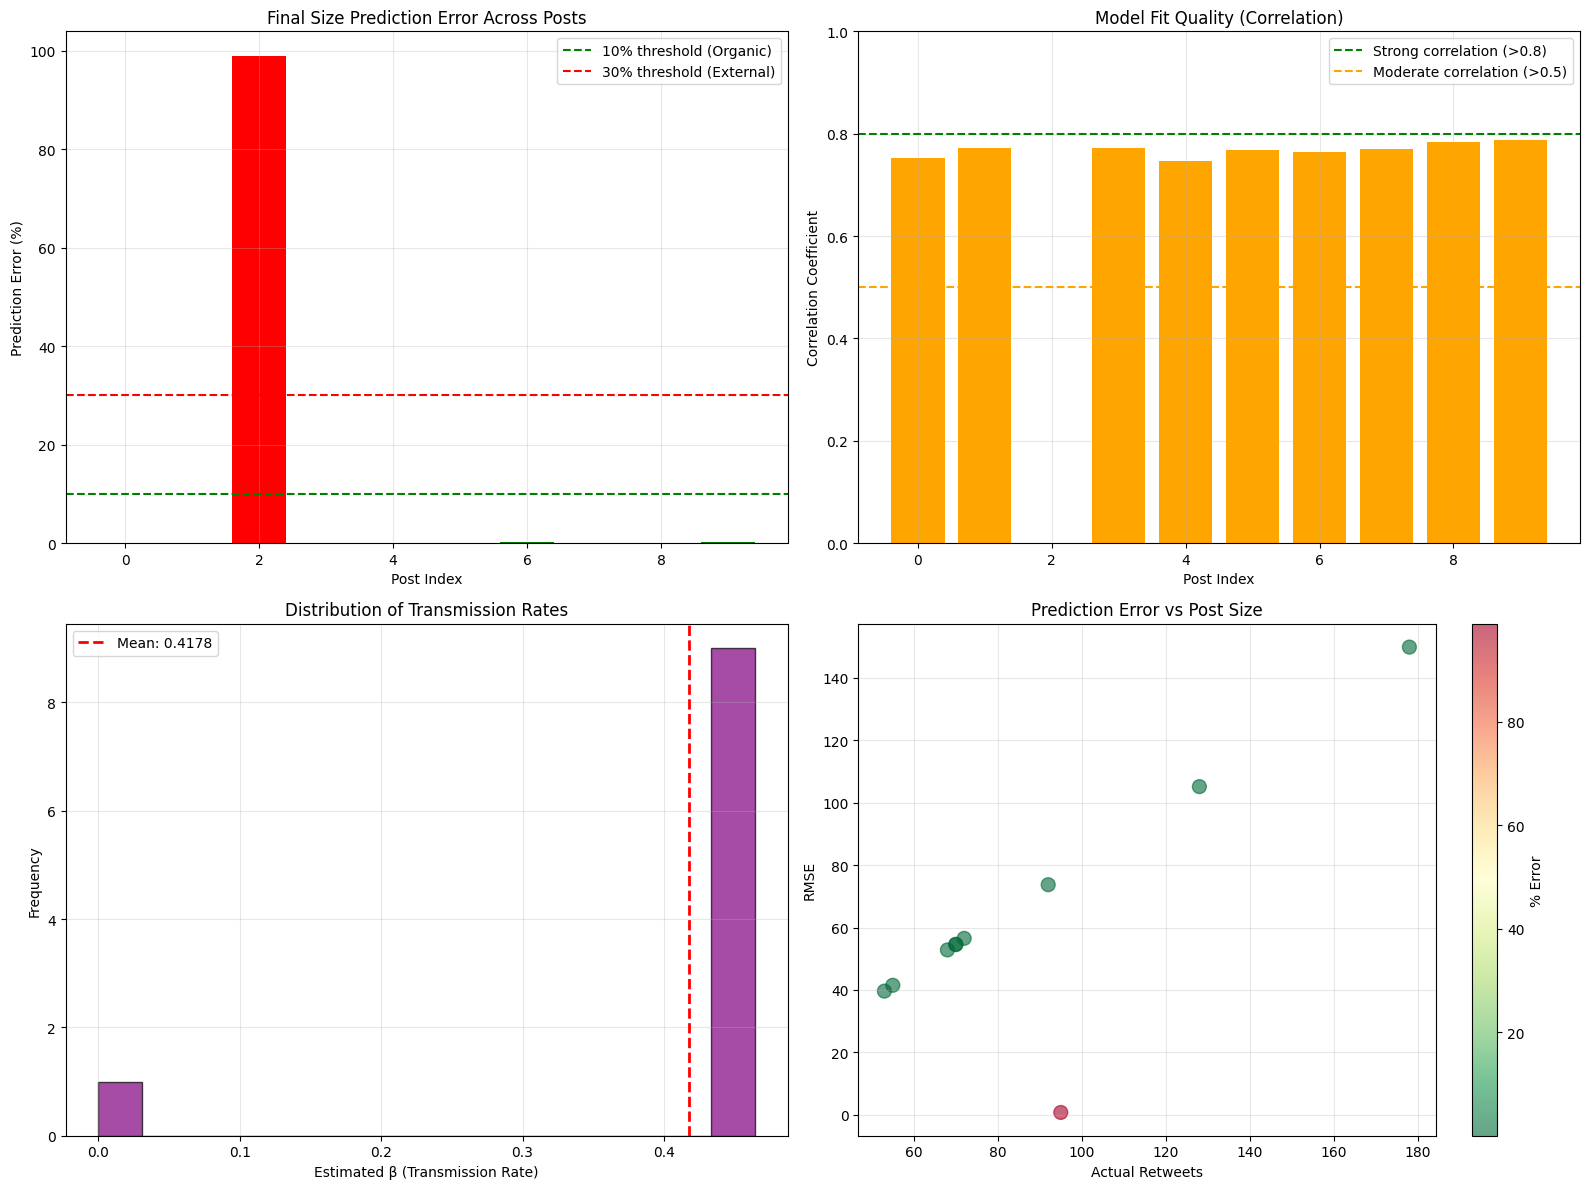

In [ ]:
def visualize_batch_results(results_df):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    ax1 = axes[0, 0]
    ax1.bar(range(len(results_df)), results_df['pct_error'], 
            color=['green' if x < 10 else 'orange' if x < 30 else 'red' 
                   for x in results_df['pct_error']])
    ax1.axhline(y=10, color='green', linestyle='--', label='10% threshold (Organic)')
    ax1.axhline(y=30, color='red', linestyle='--', label='30% threshold (External)')
    ax1.set_xlabel('Post Index')
    ax1.set_ylabel('Prediction Error (%)')
    ax1.set_title('Final Size Prediction Error Across Posts')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2 = axes[0, 1]
    colors = ['green' if x > 0.8 else 'orange' if x > 0.5 else 'red' 
              for x in results_df['correlation']]
    ax2.bar(range(len(results_df)), results_df['correlation'], color=colors)
    ax2.axhline(y=0.8, color='green', linestyle='--', label='Strong correlation (>0.8)')
    ax2.axhline(y=0.5, color='orange', linestyle='--', label='Moderate correlation (>0.5)')
    ax2.set_xlabel('Post Index')
    ax2.set_ylabel('Correlation Coefficient')
    ax2.set_title('Model Fit Quality (Correlation)')
    ax2.set_ylim([0, 1])
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    ax3 = axes[1, 0]
    ax3.hist(results_df['beta_estimated'], bins=15, color='purple', alpha=0.7, edgecolor='black')
    ax3.axvline(results_df['beta_estimated'].mean(), color='red', 
                linestyle='--', linewidth=2, label=f'Mean: {results_df["beta_estimated"].mean():.4f}')
    ax3.set_xlabel('Estimated β (Transmission Rate)')
    ax3.set_ylabel('Frequency')
    ax3.set_title('Distribution of Transmission Rates')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    ax4 = axes[1, 1]
    ax4.scatter(results_df['actual_retweets'], results_df['rmse'], 
                s=100, alpha=0.6, c=results_df['pct_error'], cmap='RdYlGn_r')
    ax4.set_xlabel('Actual Retweets')
    ax4.set_ylabel('RMSE')
    ax4.set_title('Prediction Error vs Post Size')
    ax4.grid(True, alpha=0.3)
    cbar = plt.colorbar(ax4.collections[0], ax=ax4)
    cbar.set_label('% Error')
    
    plt.tight_layout()
    plot_path = f"{OUTPUT_PREFIX}_batch_summary.png"
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"\n✓ Summary visualization saved: {plot_path}")
    plt.show()
    
    return fig

summary_fig = visualize_batch_results(batch_results)